<a href="https://colab.research.google.com/github/gettokeroro/DADS5001_MINI_PROJECT/blob/main/Job_Application_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [87]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load (relative path within the dataset)
file_path = "postings.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "arshkon/linkedin-job-postings",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

display(df.head())

Using Colab cache for faster access to the 'linkedin-job-postings' dataset.


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [89]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import os

# Base path for the dataset files
DATASET_PATH = "/kaggle/input/linkedin-job-postings/"

# Dictionary to map file names to their respective subdirectories
file_subdirs = {
    "companies.csv": "companies/",
    "company_industries.csv": "companies/",
    "employee_counts.csv": "companies/",
    "industries.csv": "mappings/",
    "skills.csv": "mappings/",
    "job_skills.csv": "jobs/",
    "job_industries.csv": "jobs/"
}

# List of additional files to load (keys of the dictionary)
additional_files = list(file_subdirs.keys())

# Load each file into a separate DataFrame
for file_name in additional_files:
    print(f"\nLoading {file_name}...")
    try:
        # Create a meaningful DataFrame name (e.g., df_companies)
        df_name = file_name.replace('.csv', '')
        # Construct the full path using the subdirectory information
        full_file_path = os.path.join(DATASET_PATH, file_subdirs[file_name], file_name)
        globals()[f'df_{df_name}'] = pd.read_csv(full_file_path)
        print(f"First 5 records of df_{df_name}:")
        display(globals()[f'df_{df_name}'].head())
    except Exception as e:
        print(f"Error loading {file_name}: {e}")

# You can now access these DataFrames using names like df_companies, df_industries, etc.


Loading companies.csv...
First 5 records of df_companies:


,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,Official LinkedIn of Hewlett Packard Enterpris...,7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packa...
3,1028,Oracle,We’re a cloud technology company that provides...,7.0,Texas,US,Austin,78741,2300 Oracle Way,https://www.linkedin.com/company/oracle
4,1033,Accenture,Accenture is a leading global professional ser...,7.0,0,IE,Dublin 2,0,Grand Canal Harbour,https://www.linkedin.com/company/accenture



Loading company_industries.csv...
First 5 records of df_company_industries:


,company_id,industry
0,391906,Book and Periodical Publishing
1,22292832,Construction
2,20300,Banking
3,3570660,Book and Periodical Publishing
4,878353,Staffing and Recruiting



Loading employee_counts.csv...
First 5 records of df_employee_counts:


...

,skill_abr,skill_name
0,ART,Art/Creative
1,DSGN,Design
2,ADVR,Advertising
3,PRDM,Product Management
4,DIST,Distribution



Loading job_skills.csv...
First 5 records of df_job_skills:


,job_id,skill_abr
0,3884428798,MRKT
1,3884428798,PR
2,3884428798,WRT
3,3887473071,SALE
4,3887465684,FIN



Loading job_industries.csv...
First 5 records of df_job_industries:


,job_id,industry_id
0,3884428798,82
1,3887473071,48
2,3887465684,41
3,3887467939,82
4,3887467939,80


# Prepare Data  & Cleansing

**1. Remove rows with NaN `company_id`**

**2. Convert `original_listed_time` and `expiry` to date format**


**3. Replace NaN with 0 in `remote_allowed`**


**4. Merge `df_job_industries` with `df_industries`**  


**5. Merge `postings` with `df_job_industries_with_names`**  


**6. The `time_record period` is too short, so I'll just use the latest row to look at the company size.**


### 1. Remove rows with NaN **company_id**

#### Dropped null values in company_id to improve job application trend analysis, as unidentified companies would skew the data.
---

In [90]:
df.dropna(subset=['company_id'], inplace=True)

### 2. Convert original_listed_time and expiry to date format

---



In [91]:
selected_columns_df = df[['original_listed_time', 'expiry']]
display(selected_columns_df.head())

,original_listed_time,expiry
0,1.713398e+12,1.715990e+12
2,1.713278e+12,1.715870e+12
3,1.712896e+12,1.715488e+12
5,1.713456e+12,1.716048e+12
6,1.712861e+12,1.715453e+12


In [92]:
selected_columns_df['original_listed_time_dt'] = pd.to_datetime(selected_columns_df['original_listed_time'], unit='ms')
selected_columns_df['expiry_dt'] = pd.to_datetime(selected_columns_df['expiry'], unit='ms')

print("DataFrame with original and converted date columns:")
display(selected_columns_df.head())

df['original_listed_time'] = pd.to_datetime(df['original_listed_time'], unit='ms')
df['expiry'] = pd.to_datetime(df['expiry'], unit='ms')

DataFrame with original and converted date columns:


/tmp/ipython-input-2618759011.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_columns_df['original_listed_time_dt'] = pd.to_datetime(selected_columns_df['original_listed_time'], unit='ms')
/tmp/ipython-input-2618759011.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_columns_df['expiry_dt'] = pd.to_datetime(selected_columns_df['expiry'], unit='ms')


,original_listed_time,expiry,original_listed_time_dt,expiry_dt
0,1.713398e+12,1.715990e+12,2024-04-17 23:45:08,2024-05-17 23:45:08
2,1.713278e+12,1.715870e+12,2024-04-16 14:26:54,2024-05-16 14:26:54
3,1.712896e+12,1.715488e+12,2024-04-12 04:23:32,2024-05-12 04:23:32
5,1.713456e+12,1.716048e+12,2024-04-18 16:01:39,2024-05-18 16:01:39
6,1.712861e+12,1.715453e+12,2024-04-11 18:43:39,2024-05-11 18:43:39


###2. Replace NaN with 0 in remote_allowed

---

In [93]:
print("Unique values in 'remote_allowed' column:")
print(df['remote_allowed'].unique())

Unique values in 'remote_allowed' column:
[nan  1.]


In [94]:
df['remote_allowed'].fillna(0, inplace=True)
print(df['remote_allowed'].unique())

[0. 1.]


/tmp/ipython-input-3893761681.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['remote_allowed'].fillna(0, inplace=True)


### 3. Merge Job Industries with Industry Names

---

In [95]:
df_job_industries_with_names = pd.merge(
    df_job_industries,
    df_industries,
    on='industry_id',
    how='left'
)

print("First 5 records of df_job_industries_with_names:")
display(df_job_industries_with_names.head())

First 5 records of df_job_industries_with_names:


,job_id,industry_id,industry_name
0,3884428798,82,Book and Periodical Publishing
1,3887473071,48,Construction
2,3887465684,41,Banking
3,3887467939,82,Book and Periodical Publishing
4,3887467939,80,Advertising Services


### 4. Merge Job Postings with Industries


In [96]:
df_merged = pd.merge(df, df_job_industries_with_names, on='job_id', how='left')

print("First 5 rows of the merged DataFrame with industry names:")
display(df_merged.head())


First 5 rows of the merged DataFrame with industry names:


,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips,industry_id,industry_name
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0,44.0,Real Estate
1,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0,32.0,Restaurants
2,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0,9.0,Law Practice
3,91700727,Downtown Raleigh Alliance,Economic Development and Planning Intern,Job summary:The Economic Development & Plannin...,20.0,HOURLY,"Raleigh, NC",1481176.0,9.0,NaN,...,NaN,0,INTERNSHIP,USD,BASE_SALARY,35360.0,27601.0,37183.0,3202.0,Non-profit Organization Management
4,103254301,Raw Cereal,Producer,Company DescriptionRaw Cereal is a creative de...,300000.0,YEARLY,United States,81942316.0,7.0,NaN,...,NaN,0,CONTRACT,USD,BASE_SALARY,180000.0,NaN,NaN,99.0,Design Services


In [97]:
del df_industries
del df_job_industries_with_names

# 5. The most up-to-date information for each company

In [98]:
df_employee_counts['time_recorded'] = pd.to_datetime(df_employee_counts['time_recorded'], unit='s')

# Sort by company_id and time_recorded to ensure the latest record is kept
df_employee_counts_cleaned = df_employee_counts.sort_values(by=['company_id', 'time_recorded'])

# Drop duplicates based on company_id, keeping the last (which is the one with max time_recorded)
df_employee_counts_cleaned = df_employee_counts_cleaned.drop_duplicates(subset='company_id', keep='last')

print("First 5 records of df_employee_counts after cleaning (one row per company_id based on max time_recorded):")
display(df_employee_counts_cleaned.head(20))

First 5 records of df_employee_counts after cleaning (one row per company_id based on max time_recorded):


,company_id,employee_count,follower_count,time_recorded
30056,1009,311223,16314846,2024-04-19 04:34:15
35604,1016,57001,2196350,2024-04-19 23:23:51
21766,1025,79559,3588329,2024-04-18 15:14:18
32109,1028,191374,9497909,2024-04-19 15:21:13
35631,1033,565191,11890321,2024-04-19 23:30:51
32107,1035,227317,22253257,2024-04-19 15:21:13
33665,1038,435078,15221049,2024-04-19 21:18:03
22303,1043,217641,6814908,2024-04-18 16:24:32
22629,1044,291883,6085704,2024-04-18 16:45:10
32426,1052,174692,1485885,2024-04-19 18:14:17


# Analysis

---

#**Overview Data**

In [101]:
df_merged['year'] = df_merged['original_listed_time'].dt.year

df_yearly_metrics = df_merged.groupby('year').agg(
     distinct_company_ids=('company_id', 'nunique'),
     distinct_job_titles=('title', 'nunique'),
     total_applies=('applies', 'sum'),
     total_views=('views', 'sum')
 ).reset_index()

# Apply string formatting to the desired columns (this should be done only once or on a copy for display)
df_yearly_metrics['distinct_company_ids'] = df_yearly_metrics['distinct_company_ids'].astype(int).apply(lambda x: f"{x:,}")
df_yearly_metrics['distinct_job_titles'] = df_yearly_metrics['distinct_job_titles'].astype(int).apply(lambda x: f"{x:,}")
df_yearly_metrics['total_applies'] = df_yearly_metrics['total_applies'].fillna(0).astype(int).apply(lambda x: f"{x:,}")
df_yearly_metrics['total_views'] = df_yearly_metrics['total_views'].fillna(0).astype(int).apply(lambda x: f"{x:,}")

print("Yearly metrics (distinct job titles, total applies, total views):")
display(df_yearly_metrics.head())

Yearly metrics (distinct job titles, total applies, total views):


,year,distinct_company_ids,distinct_job_titles,total_applies,total_views
0,2023,2,2,6,527
1,2024,"24,473","71,879","334,021","2,418,116"


## Filter Data for 2024


In [111]:
df_2024 = df_merged[df_merged['year'] == 2024]

In [103]:
df_2024_industry_metrics = df_2024.groupby('industry_name')[['applies', 'views']].sum().reset_index()
print("First 5 rows of df_2024_industry_metrics:")
display(df_2024_industry_metrics.head())

First 5 rows of df_2024_industry_metrics:


,industry_name,applies,views
0,Abrasives and Nonmetallic Minerals Manufacturing,0.0,2.0
1,Accessible Architecture and Design,1.0,45.0
2,Accommodation and Food Services,4.0,91.0
3,Accounting,1533.0,15737.0
4,Administration of Justice,4.0,119.0


**Reasoning**:
To visualize the proportion of applications per industry in 2024, I will create a pie chart using `df_2024_industry_metrics`. I will filter out industries with zero applications for better visualization and ensure a clear title and labels.



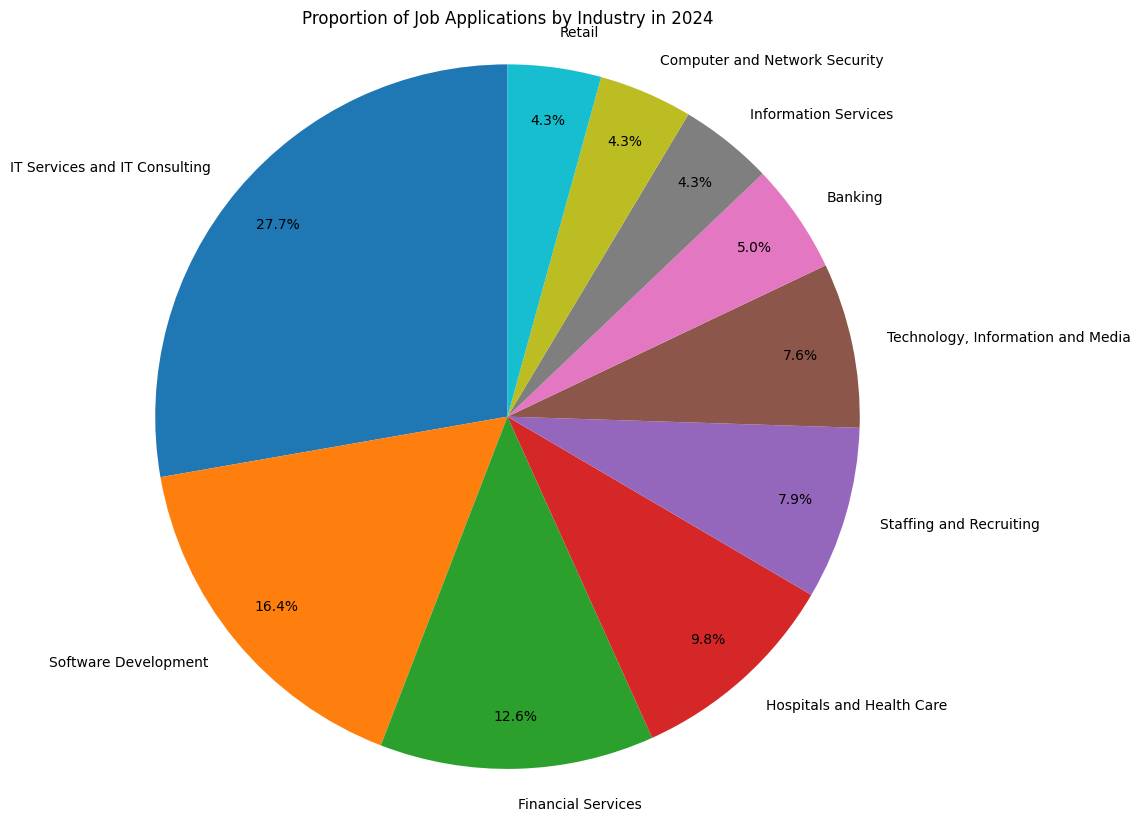

In [108]:
import matplotlib.pyplot as plt

# Filter out industries with 0 applies for better visualization
df_applies_plot = df_2024_industry_metrics[df_2024_industry_metrics['applies'] > 0]

# Sort by applies for better pie chart representation (largest slices first)
df_applies_plot = df_applies_plot.sort_values(by='applies', ascending=False)

# Select top N industries or all if less than N for clarity
# Let's consider industries that contribute significantly, e.g., top 10 or industries with > 1% of total applies
total_applies_2024 = df_applies_plot['applies'].sum()

# Identify industries that contribute to at least 1% of total applies, or top 10 if more than 10 are significant
significant_applies = df_applies_plot[df_applies_plot['applies'] / total_applies_2024 > 0.01]

if len(significant_applies) < 10 and len(df_applies_plot) > 10: # If less than 10 significant, take top 10
    df_applies_plot_final = df_applies_plot.head(10)
else:
    df_applies_plot_final = significant_applies

# If there are still too many, just take top 10 to keep the chart readable
if len(df_applies_plot_final) > 10:
    df_applies_plot_final = df_applies_plot.head(10)

# Add an 'Other' category if some industries were filtered out
'''
if len(df_applies_plot_final) < len(df_applies_plot):
    other_applies_sum = df_applies_plot[~df_applies_plot['industry_name'].isin(df_applies_plot_final['industry_name'])]['applies'].sum()
    if other_applies_sum > 0: # Only add 'Other' if it has applications
        other_row = pd.DataFrame([{'industry_name': 'Other', 'applies': other_applies_sum}])
        df_applies_plot_final = pd.concat([df_applies_plot_final, other_row], ignore_index=True)
'''


plt.figure(figsize=(10, 10))
plt.pie(df_applies_plot_final['applies'], labels=df_applies_plot_final['industry_name'], autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Proportion of Job Applications by Industry in 2024')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


**Reasoning**:
To visualize the proportion of views per industry in 2024, I will create a second pie chart using `df_2024_industry_metrics`. Similar to the applications chart, I will filter out industries with zero views, sort them, and aggregate smaller industries into an 'Other' category to maintain clarity in the visualization. I will then display the chart.



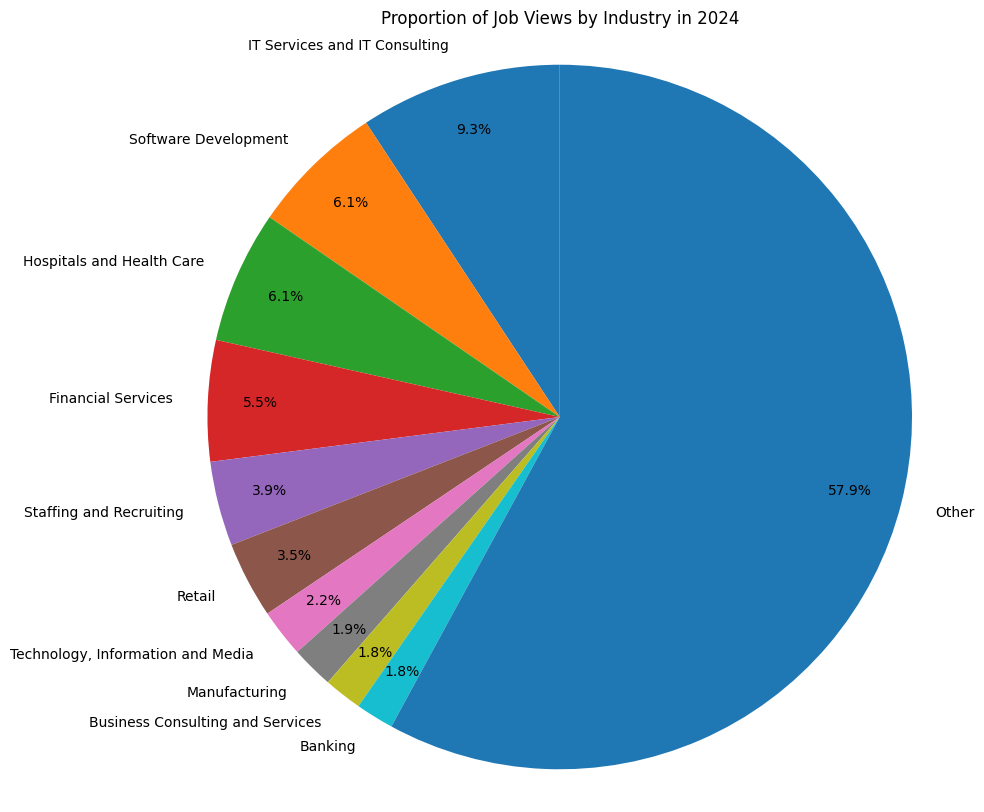

In [105]:
import matplotlib.pyplot as plt

# Filter out industries with 0 views for better visualization
df_views_plot = df_2024_industry_metrics[df_2024_industry_metrics['views'] > 0]

# Sort by views for better pie chart representation (largest slices first)
df_views_plot = df_views_plot.sort_values(by='views', ascending=False)

# Select top N industries or all if less than N for clarity
total_views_2024 = df_views_plot['views'].sum()

# Identify industries that contribute to at least 1% of total views, or top 10 if more than 10 are significant
significant_views = df_views_plot[df_views_plot['views'] / total_views_2024 > 0.01]

if len(significant_views) < 10 and len(df_views_plot) > 10: # If less than 10 significant, take top 10
    df_views_plot_final = df_views_plot.head(10)
else:
    df_views_plot_final = significant_views

# If there are still too many, just take top 10 to keep the chart readable
if len(df_views_plot_final) > 10:
    df_views_plot_final = df_views_plot.head(10)

# Add an 'Other' category if some industries were filtered out
if len(df_views_plot_final) < len(df_views_plot):
    other_views_sum = df_views_plot[~df_views_plot['industry_name'].isin(df_views_plot_final['industry_name'])]['views'].sum()
    if other_views_sum > 0: # Only add 'Other' if it has views
        other_row_views = pd.DataFrame([{'industry_name': 'Other', 'views': other_views_sum}])
        df_views_plot_final = pd.concat([df_views_plot_final, other_row_views], ignore_index=True)

plt.figure(figsize=(10, 10))
plt.pie(df_views_plot_final['views'], labels=df_views_plot_final['industry_name'], autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Proportion of Job Views by Industry in 2024')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### Insights from Job Applications and Views by Industry in 2024

**Job Applications Pie Chart Insights:**

*   **IT Services and IT Consulting** dominates the job application landscape, indicating a high demand or interest in roles within this sector.
*   **Software Development** and **Financial Services** also attract a significant proportion of applications, highlighting their continued importance in the job market.
*   **Hospitals and Health Care** and **Staffing and Recruiting** show considerable application activity, suggesting robust hiring or persistent job searching in these areas.
*   The presence of an 'Other' category with a substantial percentage implies that a wide array of smaller industries collectively contribute significantly to the total applications, reflecting a diverse job market beyond the top few sectors.

**Job Views Pie Chart Insights:**

*   Similar to applications, **IT Services and IT Consulting** leads in job views, reinforcing its prominent position in attracting job seekers' attention.
*   **Software Development** and **Hospitals and Health Care** also rank high in terms of views, aligning with their strong performance in applications.
*   **Financial Services** and **Staffing and Recruiting** continue to be among the most viewed industries, indicating active job search interest.
*   The **Retail** industry, while not as high in applications, shows a notable percentage of views, which could suggest a large volume of available positions or a broad appeal to job seekers.
*   The 'Other' category for views is even larger than for applications, suggesting that job seekers browse a very diverse set of industries, even if their applications concentrate on a few major ones.

In [106]:
# Identify industries in the 'Other' category for applications
industries_in_other_applies = df_applies_plot[~df_applies_plot['industry_name'].isin(df_applies_plot_final[df_applies_plot_final['industry_name'] != 'Other']['industry_name'])]

print("Industries making up the 'Other' category in Job Applications:")
display(industries_in_other_applies[['industry_name', 'applies']].sort_values(by='applies', ascending=False))

Industries making up the 'Other' category in Job Applications:


,industry_name,applies
6,Advertising Services,6529.0
248,Pharmaceutical Manufacturing,6142.0
328,"Technology, Information and Internet",5911.0
168,Insurance,5804.0
194,Manufacturing,5551.0
...,...,...
74,Correctional Institutions,1.0
343,Trusts and Estates,1.0
333,Theater Companies,1.0
46,Caterers,1.0


In [107]:
# Identify industries in the 'Other' category for views
industries_in_other_views = df_views_plot[~df_views_plot['industry_name'].isin(df_views_plot_final[df_views_plot_final['industry_name'] != 'Other']['industry_name'])]

print("Industries making up the 'Other' category in Job Views:")
display(industries_in_other_views[['industry_name', 'views']].sort_values(by='views', ascending=False))

Industries making up the 'Other' category in Job Views:


,industry_name,views
328,"Technology, Information and Internet",42064.0
168,Insurance,41453.0
248,Pharmaceutical Manufacturing,40883.0
269,Real Estate,40238.0
102,Entertainment Providers,39706.0
...,...,...
295,Retail Musical Instruments,2.0
78,Dairy,2.0
40,Building Equipment Contractors,2.0
367,Wholesale Footwear,2.0


## Final Task

### Subtask:
Summarize the key insights derived from the pie charts regarding industry distribution of applications and views in 2024.


# Task
Prepare the 'zip_code' column in `df_2024` by converting it to string type and removing any rows where the zip code is missing.

## Prepare Zip Code Data for Mapping

### Subtask:
Clean the 'zip_code' column in `df_2024` by removing missing values and ensuring it's in a consistent string format suitable for mapping.


**Reasoning**:
To clean the 'zip_code' column as instructed, I will first remove rows with missing values in this column, and then convert the column to a string data type to ensure consistency for mapping.



In [116]:
df_2024.dropna(subset=['zip_code'], inplace=True)
df_2024['zip_code'] = df_2024['zip_code'].astype(int).astype(str)

print("Info of df_2024 after cleaning 'zip_code':")
df_2024.info()
print("\nFirst 5 unique zip codes in df_2024:")
print(df_2024['zip_code'].head())

Info of df_2024 after cleaning 'zip_code':
<class 'pandas.core.frame.DataFrame'>
Index: 121933 entries, 0 to 158448
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   job_id                      121933 non-null  int64         
 1   company_name                121931 non-null  object        
 2   title                       121933 non-null  object        
 3   description                 121931 non-null  object        
 4   max_salary                  29547 non-null   float64       
 5   pay_period                  35662 non-null   object        
 6   location                    121933 non-null  object        
 7   company_id                  121933 non-null  float64       
 8   views                       120151 non-null  float64       
 9   med_salary                  6115 non-null    float64       
 10  min_salary                  29547 non-null   float64       
 11  f

/tmp/ipython-input-861645816.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-861645816.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



**Reasoning**:
The previous execution successfully cleaned the 'zip_code' column but produced `SettingWithCopyWarning` warnings. To prevent these warnings and ensure operations are performed on an independent DataFrame, I will explicitly create a copy of `df_2024` before dropping rows and converting the column type.



In [117]:
df_2024 = df_2024.copy()
df_2024.dropna(subset=['zip_code'], inplace=True)
df_2024['zip_code'] = df_2024['zip_code'].astype(int).astype(str)

print("Info of df_2024 after cleaning 'zip_code':")
df_2024.info()
print("\nFirst 5 unique zip codes in df_2024:")
print(df_2024['zip_code'].head())

Info of df_2024 after cleaning 'zip_code':
<class 'pandas.core.frame.DataFrame'>
Index: 121933 entries, 0 to 158448
Data columns (total 34 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   job_id                      121933 non-null  int64         
 1   company_name                121931 non-null  object        
 2   title                       121933 non-null  object        
 3   description                 121931 non-null  object        
 4   max_salary                  29547 non-null   float64       
 5   pay_period                  35662 non-null   object        
 6   location                    121933 non-null  object        
 7   company_id                  121933 non-null  float64       
 8   views                       120151 non-null  float64       
 9   med_salary                  6115 non-null    float64       
 10  min_salary                  29547 non-null   float64       
 11  f